In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers[1].csv to Mall_Customers[1].csv


Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


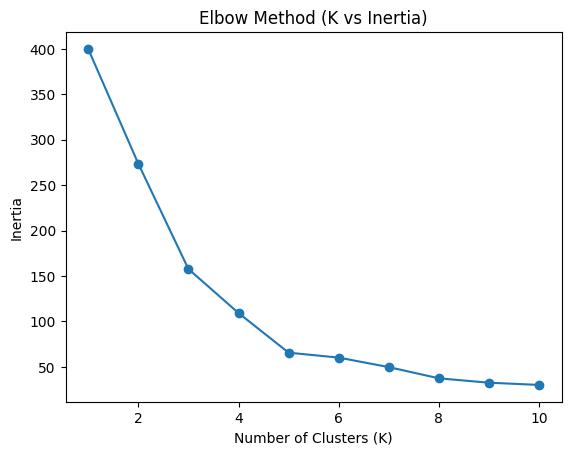


=== K-MEANS RESULTS ===
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


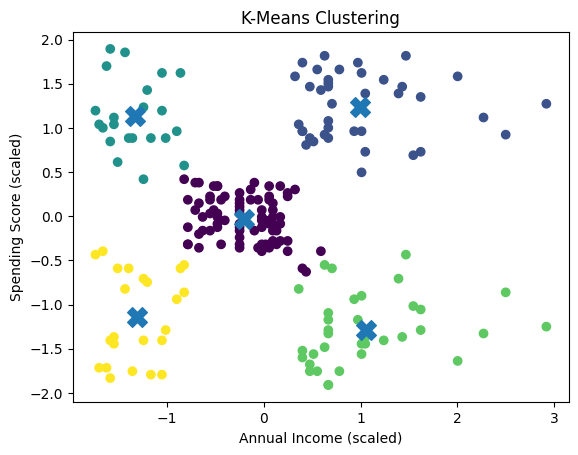


Cluster Centers (Scaled):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [4]:
# ==============================
# STEP 2: IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==============================
# STEP 3: LOAD DATASET
# ==============================
df = pd.read_csv("Mall_Customers[1].csv")

print("Dataset Preview:")
print(df.head())

# ==============================
# STEP 4: SELECT FEATURES
# ==============================
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ==============================
# STEP 5: PREPROCESSING (SCALING)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# STEP 6: ELBOW METHOD
# ==============================
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# ==============================
# STEP 7: APPLY K-MEANS
# ==============================
optimal_k = 5   # choose based on elbow

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# ==============================
# STEP 8: EVALUATION METRICS
# ==============================
inertia_value = kmeans.inertia_
silhouette = silhouette_score(X_scaled, labels)

print("\n=== K-MEANS RESULTS ===")
print("Inertia:", inertia_value)
print("Silhouette Score:", silhouette)

# ==============================
# STEP 9: VISUALIZATION
# ==============================
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# ==============================
# STEP 10: INTERPRETATION
# ==============================
print("\nCluster Centers (Scaled):")
print(kmeans.cluster_centers_)